# Explainable AI Dashboard (Model Interpretation System)

## Project Overview
This project builds a machine learning system that not only predicts outcomes but also explains WHY the prediction was made.

## Objectives
- Train a classification model
- Generate predictions
- Interpret model decisions using Explainable AI (SHAP)
- Visualize feature importance and impact

## Key Features
- Model prediction (classification)
- Feature importance ranking
- SHAP-based explanation
- Visualization of feature impact

## Technologies Used
- Python
- Pandas, NumPy
- Scikit-learn
- SHAP
- Matplotlib, Seaborn

## Workflow
1. Load dataset
2. Data preprocessing
3. Train ML model
4. Generate predictions
5. Explain predictions using SHAP
6. Visualize feature importance

## Output
- Prediction results
- Feature importance plots
- SHAP explanation graphs
- Model insights


Dataset Preview:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

/tmp/ipykernel_3968/2205366085.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)



Model Accuracy: 0.79


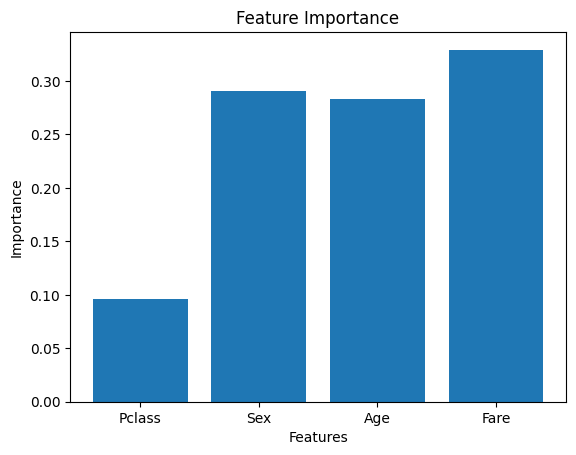

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [1]:
# ===============================
# EXPLAINABLE AI SYSTEM
# ===============================

# Install SHAP (run once in Colab)
!pip install shap

# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# -------------------------------
# 2. LOAD DATASET
# -------------------------------

# Using Titanic dataset (classification problem)
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print("Dataset Preview:")
print(df.head())

# -------------------------------
# 3. DATA PREPROCESSING
# -------------------------------

# Drop unnecessary columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# Handle missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Encode categorical data
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

print("\nCleaned Dataset:")
print(df.head())

# -------------------------------
# 4. TRAIN-TEST SPLIT
# -------------------------------

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 5. TRAIN MODEL
# -------------------------------

model = RandomForestClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"\nModel Accuracy: {accuracy:.2f}")

# -------------------------------
# 6. FEATURE IMPORTANCE
# -------------------------------

importance = model.feature_importances_

plt.figure()
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# -------------------------------
# 7. SHAP EXPLAINABILITY
# -------------------------------

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values[1], X_test)

# Force plot (single prediction)
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test.iloc[0])

# -------------------------------
# 8. VISUAL ANALYSIS
# -------------------------------

# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Distribution plots
plt.figure()
df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

# -------------------------------
# 9. INSIGHTS
# -------------------------------

print("\nInsights:")
print("- Model predicts survival based on features")
print("- SHAP explains how each feature affects prediction")
print("- Feature importance shows key influencing factors")
print("- This improves model transparency and trust")
